Environment Setup, Data Loading, and Advanced EDA

--- Training Data Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230130 entries, 0 to 230129
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   id        230130 non-null  int64         
 1   date      230130 non-null  datetime64[ns]
 2   country   230130 non-null  object        
 3   store     230130 non-null  object        
 4   product   230130 non-null  object        
 5   num_sold  221259 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 10.5+ MB
None

--- Missing Values in Training Data ---
id             0
date           0
country        0
store          0
product        0
num_sold    8871
dtype: int64

--- Unique Categories ---
Countries: ['Canada' 'Finland' 'Italy' 'Kenya' 'Norway' 'Singapore']
Stores: ['Discount Stickers' 'Stickers for Less' 'Premium Sticker Mart']
Products: ['Holographic Goose' 'Kaggle' 'Kaggle Tiers' 'Kerneler'
 'Ker

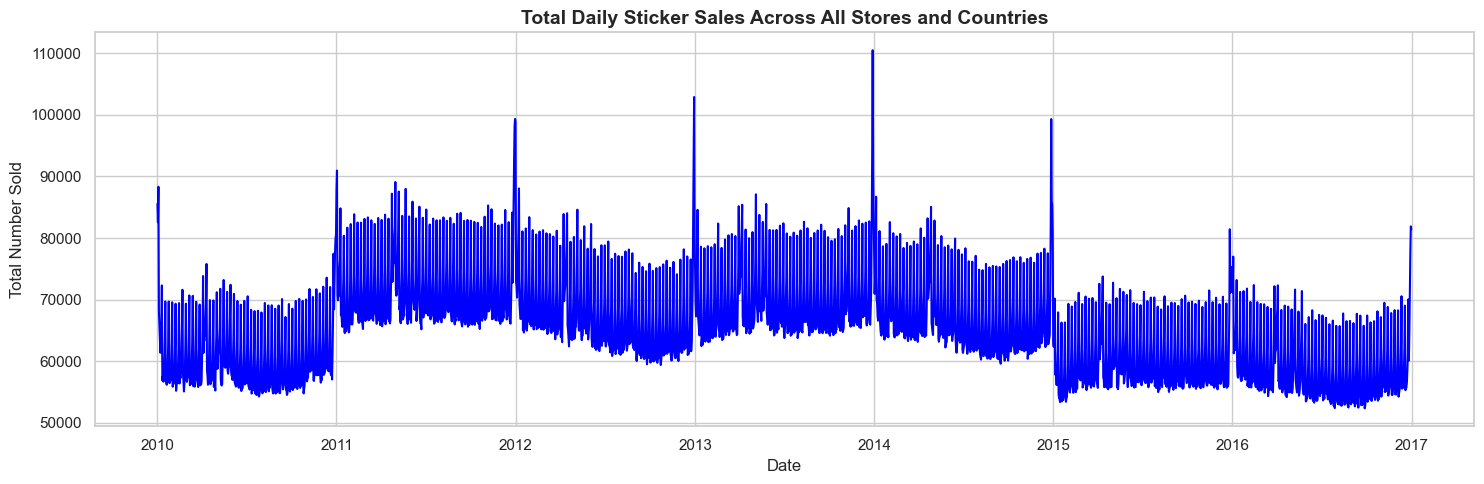

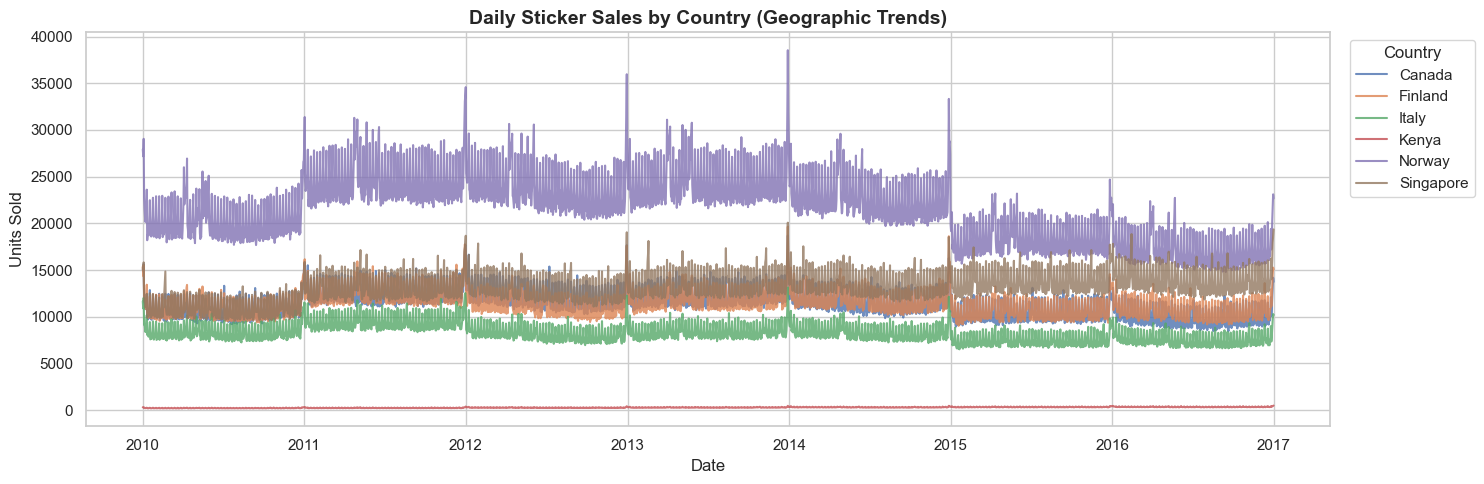

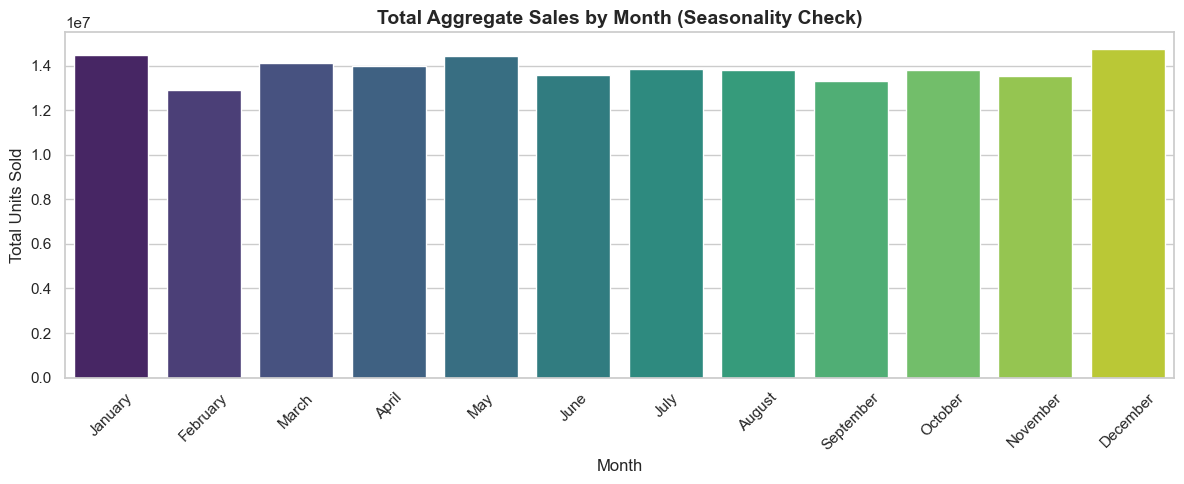

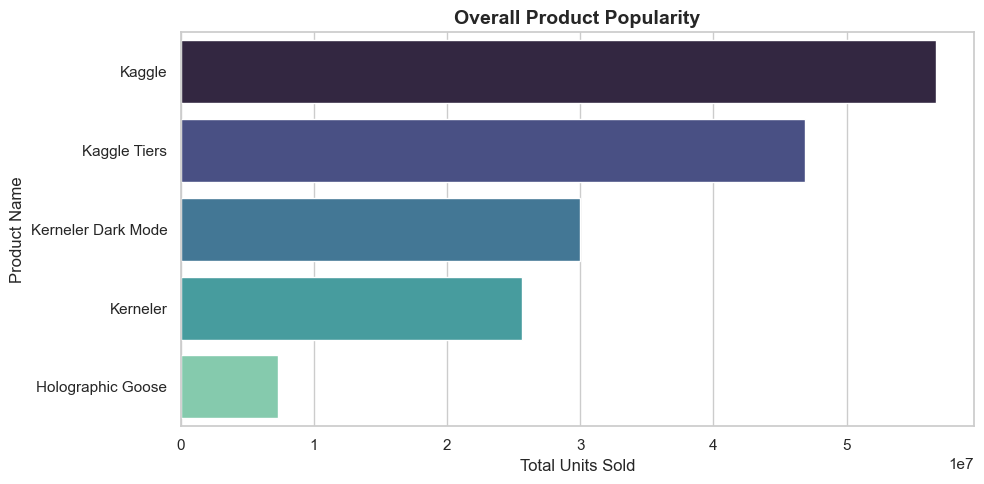


✅ Step 1 execution completed successfully. Ready for Step 2.


In [16]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

def load_and_inspect_data(train_path='train.csv', test_path='test.csv'):
    """Loads the Kaggle datasets and prints structural overviews."""
    try:
        train_df = pd.read_csv(train_path)
        test_df = pd.read_csv(test_path)
    except FileNotFoundError:
        print("Error: Dataset files not found. Please ensure train.csv and test.csv are in the correct directory.")
        return None, None

    # Convert date columns to pandas datetime objects for time-series processing
    train_df['date'] = pd.to_datetime(train_df['date'])
    test_df['date'] = pd.to_datetime(test_df['date'])

    print("--- Training Data Overview ---")
    print(train_df.info())
    print("\n--- Missing Values in Training Data ---")
    print(train_df.isnull().sum())
    
    print("\n--- Unique Categories ---")
    print(f"Countries: {train_df['country'].unique()}")
    print(f"Stores: {train_df['store'].unique()}")
    print(f"Products: {train_df['product'].unique()}")
    
    print("\n--- Summary Statistics ---")
    print(train_df.describe(include='all'))

    return train_df, test_df

def perform_advanced_eda(train_df):
    """Generates report-ready visualizations to satisfy top-tier EDA marks."""
    print("\nGenerating Advanced Exploratory Data Analysis Visualizations...")
    sns.set_theme(style="whitegrid")
    
    # 1. Total Daily Sales (Baseline Temporal Trend)
    plt.figure(figsize=(15, 5))
    daily_sales = train_df.groupby('date')['num_sold'].sum().reset_index()
    sns.lineplot(data=daily_sales, x='date', y='num_sold', color='blue')
    plt.title('Total Daily Sticker Sales Across All Stores and Countries', fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Total Number Sold', fontsize=12)
    plt.tight_layout()
    plt.show()

    # 2. Sales Distribution by Country over Time
    plt.figure(figsize=(15, 5))
    country_sales = train_df.groupby(['date', 'country'])['num_sold'].sum().reset_index()
    sns.lineplot(data=country_sales, x='date', y='num_sold', hue='country', alpha=0.8)
    plt.title('Daily Sticker Sales by Country (Geographic Trends)', fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Units Sold', fontsize=12)
    plt.legend(title='Country', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # 3. Monthly Seasonality Analysis (Aggregated across all years)
    plt.figure(figsize=(12, 5))
    train_df_copy = train_df.copy()
    train_df_copy['month_name'] = train_df_copy['date'].dt.month_name()
    months_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                    'July', 'August', 'September', 'October', 'November', 'December']
    monthly_sales = train_df_copy.groupby('month_name')['num_sold'].sum().reindex(months_order).reset_index()
    sns.barplot(data=monthly_sales, x='month_name', y='num_sold', palette='viridis')
    plt.title('Total Aggregate Sales by Month (Seasonality Check)', fontsize=14, fontweight='bold')
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Total Units Sold', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 4. Product Popularity Distribution
    plt.figure(figsize=(10, 5))
    product_sales = train_df.groupby('product')['num_sold'].sum().sort_values(ascending=False).reset_index()
    sns.barplot(data=product_sales, y='product', x='num_sold', palette='mako')
    plt.title('Overall Product Popularity', fontsize=14, fontweight='bold')
    plt.ylabel('Product Name', fontsize=12)
    plt.xlabel('Total Units Sold', fontsize=12)
    plt.tight_layout()
    plt.show()

# Execute Step 1
train_data, test_data = load_and_inspect_data()

if train_data is not None:
    perform_advanced_eda(train_data)
    print("\n✅ Step 1 execution completed successfully. Ready for Step 2.")

Feature Engineering

In [17]:

import pandas as pd
import numpy as np

def engineer_features(df):
    """
    Creates time-based, cyclical, and categorical encoded features 
    essential for time-series forecasting.
    """
    df = df.copy()
    
    # Extract standard time-based features
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['is_weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)
    
    # Cyclical features to capture annual and weekly seasonality
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7.0)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7.0)
    
    # One-hot encode categorical variables
    df = pd.get_dummies(df, columns=['country', 'store', 'product'], drop_first=False)
    
    # Convert any boolean columns from get_dummies to integers for model compatibility
    for col in df.select_dtypes(include=['bool']).columns:
        df[col] = df[col].astype(int)
        
    return df

def preprocess_data(train_df, test_df):
    """Applies feature engineering and aligns train/test dimensions."""
    print("Starting feature engineering pipeline...")
    
    train_processed = engineer_features(train_df)
    test_processed = engineer_features(test_df)
    
    # Align columns to ensure test set exactly matches train set's one-hot encodings
    train_processed, test_processed = train_processed.align(test_processed, join='left', axis=1, fill_value=0)
    
    # Exclude the target variable from the test set alignment
    if 'num_sold' in test_processed.columns:
        test_processed = test_processed.drop('num_sold', axis=1)
        
    print("✅ Feature engineering complete.")
    print(f"Processed training shape: {train_processed.shape}")
    print(f"Processed test shape: {test_processed.shape}")
    
    return train_processed, test_processed

# Execute Step 2
try:
    train_processed, test_processed = preprocess_data(train_data, test_data)
    print("\n--- Processed Training Data Sample ---")
    print(train_processed.head())
except NameError:
    print("Error: train_data or test_data not defined. Please run Step 1 data loading first.")

Starting feature engineering pipeline...
✅ Feature engineering complete.
Processed training shape: (230130, 26)
Processed test shape: (98550, 25)

--- Processed Training Data Sample ---
   id       date  num_sold  year  month  day  dayofweek  is_weekend  \
0   0 2010-01-01       NaN  2010      1    1          4           0   
1   1 2010-01-01     973.0  2010      1    1          4           0   
2   2 2010-01-01     906.0  2010      1    1          4           0   
3   3 2010-01-01     423.0  2010      1    1          4           0   
4   4 2010-01-01     491.0  2010      1    1          4           0   

   month_sin  month_cos  ...  country_Norway  country_Singapore  \
0        0.5   0.866025  ...               0                  0   
1        0.5   0.866025  ...               0                  0   
2        0.5   0.866025  ...               0                  0   
3        0.5   0.866025  ...               0                  0   
4        0.5   0.866025  ...               0        


Model Training and Evaluation


Preparing data for modeling...
Building and training Deep Learning model...
Epoch 1/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 187138.7656 - mae: 229.1834 - val_loss: 35163.5156 - val_mae: 118.7221
Epoch 2/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 27090.0234 - mae: 99.6939 - val_loss: 34023.4570 - val_mae: 107.1308
Epoch 3/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 24182.6621 - mae: 92.8204 - val_loss: 29945.3262 - val_mae: 98.1621
Epoch 4/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 23288.5410 - mae: 90.5144 - val_loss: 28977.3184 - val_mae: 95.4957
Epoch 5/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 22300.6172 - mae: 88.9118 - val_loss: 26024.3223 - val_mae: 92.2804
Epoch 6/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 21774.8047 - mae: 87.8567 - val_loss: 22457.9785 - val_mae: 86.5814
Epoch 7/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 21418.7070 - mae: 86.8993 - val_loss: 20448.9395 - val_mae: 84.7197
Epoch 8/30
692/692 ━━━━

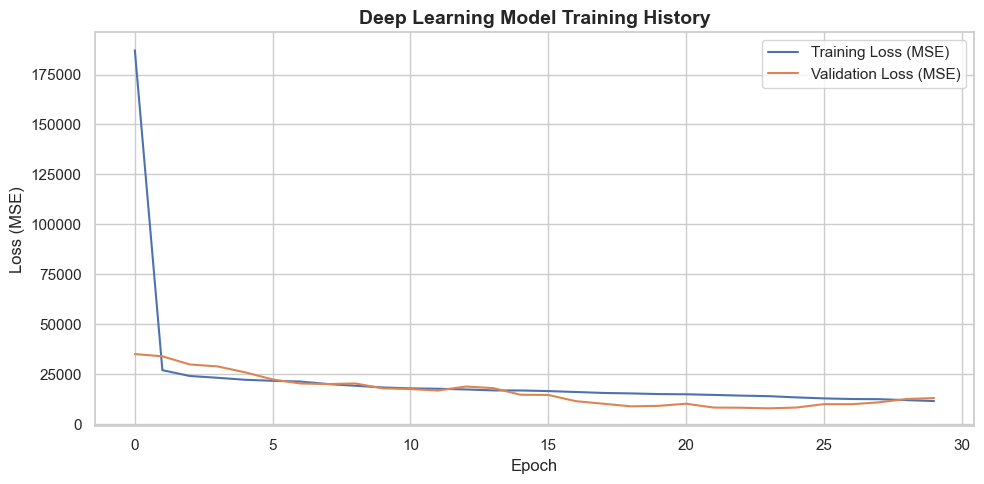


✅ Step 3 execution completed successfully. Ready for Step 4.


In [18]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
import numpy as np

def prepare_and_train_model(train_df, test_df):
    """Prepares data, scales features, and trains a Deep Learning model."""
    print("Preparing data for modeling...")
    
    # Clean missing target values
    train_clean = train_df.dropna(subset=['num_sold']).copy()
    
    # Separate features (X) and target (y)
    X = train_clean.drop(['id', 'date', 'num_sold'], axis=1)
    y = train_clean['num_sold']
    
    # Train-Validation Split (chronological split is crucial for time series)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)
    
    # Feature Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Prepare test set for final predictions later
    X_test = test_df.drop(['id', 'date', 'num_sold'], axis=1, errors='ignore')
    X_test_scaled = scaler.transform(X_test)
    
    print("Building and training Deep Learning model...")
    tf.random.set_seed(42)
    
    # Build the Deep Learning Model Architecture
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    # Train the model
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=30,
        batch_size=256,
        verbose=1
    )
    
    # Evaluate the model
    print("\nEvaluating model on validation set...")
    val_predictions = model.predict(X_val_scaled)
    mae = mean_absolute_error(y_val, val_predictions)
    rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
    
    print(f"Validation Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Validation Root Mean Squared Error (RMSE): {rmse:.2f}")
    
    return model, history, scaler, X_test_scaled

# Execute Step 3
try:
    dl_model, training_history, feature_scaler, X_test_ready = prepare_and_train_model(train_processed, test_processed)
    
    plt.figure(figsize=(10, 5))
    plt.plot(training_history.history['loss'], label='Training Loss (MSE)')
    plt.plot(training_history.history['val_loss'], label='Validation Loss (MSE)')
    plt.title('Deep Learning Model Training History', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (MSE)', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Step 3 execution completed successfully. Ready for Step 4.")
except NameError:
    print("Error: train_processed or test_processed not defined. Please run Step 2 feature engineering first.")


Generating Predictions and Saving Artifacts


In [19]:

import pandas as pd
import joblib

def generate_submission_and_save_artifacts(model, scaler, test_df, X_test_scaled):
    """
    Predicts on the test set, formats the Kaggle submission file, 
    and exports the trained model and scaler for the web app.
    """
    print("Generating final predictions for Kaggle submission...")
    
    # Generate predictions on the preprocessed test set
    predictions = model.predict(X_test_scaled)
    
    # Format the submission DataFrame according to Kaggle's requirements
    submission_df = pd.DataFrame({
        'id': test_df['id'],
        'num_sold': predictions.flatten()  # Flatten ensures the output is a 1D array
    })
    
    # Save the submission file to disk
    submission_path = 'submission.csv'
    submission_df.to_csv(submission_path, index=False)
    print(f"✅ Kaggle submission saved successfully to: {submission_path}")
    
    # Save the trained model and scaler for the application deployment phase
    print("\nSaving model and scaler artifacts for application deployment...")
    model_path = 'sticker_sales_model.h5'
    scaler_path = 'feature_scaler.pkl'
    
    model.save(model_path)
    joblib.dump(scaler, scaler_path)
    
    print(f"✅ Model saved to: {model_path}")
    print(f"✅ Scaler saved to: {scaler_path}")
    
    return submission_df

# Execute Step 4
try:
    submission = generate_submission_and_save_artifacts(
        model=dl_model, 
        scaler=feature_scaler, 
        test_df=test_data, 
        X_test_scaled=X_test_ready
    )
    
    print("\n--- Final Submission Data Sample ---")
    print(submission.head())
    print("\n✅ Step 4 execution completed successfully. Ready for Step 5 (App Deployment).")
except NameError:
    print("Error: Required variables are not defined. Please ensure you have run Step 3 successfully.")
import pandas as pd
import joblib

def generate_submission_and_save_artifacts(model, scaler, test_df, X_test_scaled):
    """
    Predicts on the test set, formats the Kaggle submission file, 
    and exports the trained model and scaler for the web app.
    """
    print("Generating final predictions for Kaggle submission...")
    
    # Generate predictions on the preprocessed test set
    predictions = model.predict(X_test_scaled)
    
    # Format the submission DataFrame according to Kaggle's requirements
    submission_df = pd.DataFrame({
        'id': test_df['id'],
        'num_sold': predictions.flatten()  # Flatten ensures the output is a 1D array
    })
    
    # Save the submission file to disk
    submission_path = 'submission.csv'
    submission_df.to_csv(submission_path, index=False)
    print(f"✅ Kaggle submission saved successfully to: {submission_path}")
    
    # Save the trained model and scaler for the application deployment phase
    print("\nSaving model and scaler artifacts for application deployment...")
    model_path = 'sticker_sales_model.h5'
    scaler_path = 'feature_scaler.pkl'
    
    model.save(model_path)
    joblib.dump(scaler, scaler_path)
    
    print(f"✅ Model saved to: {model_path}")
    print(f"✅ Scaler saved to: {scaler_path}")
    
    return submission_df

# Execute Step 4
try:
    submission = generate_submission_and_save_artifacts(
        model=dl_model, 
        scaler=feature_scaler, 
        test_df=test_data, 
        X_test_scaled=X_test_ready
    )
    
    print("\n--- Final Submission Data Sample ---")
    print(submission.head())
    print("\n✅ Step 4 execution completed successfully. Ready for Step 5 (App Deployment).")
except NameError:
    print("Error: Required variables are not defined. Please ensure you have run Step 3 successfully.")

Generating final predictions for Kaggle submission...
3080/3080 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step


✅ Kaggle submission saved successfully to: submission.csv

Saving model and scaler artifacts for application deployment...
✅ Model saved to: sticker_sales_model.h5
✅ Scaler saved to: feature_scaler.pkl

--- Final Submission Data Sample ---
       id    num_sold
0  230130  194.259811
1  230131  668.878235
2  230132  563.240662
3  230133  358.448334
4  230134  436.179932

✅ Step 4 execution completed successfully. Ready for Step 5 (App Deployment).
Generating final predictions for Kaggle submission...
3080/3080 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step


✅ Kaggle submission saved successfully to: submission.csv

Saving model and scaler artifacts for application deployment...
✅ Model saved to: sticker_sales_model.h5
✅ Scaler saved to: feature_scaler.pkl

--- Final Submission Data Sample ---
       id    num_sold
0  230130  194.259811
1  230131  668.878235
2  230132  563.240662
3  230133  358.448334
4  230134  436.179932

✅ Step 4 execution completed successfully. Ready for Step 5 (App Deployment).
